In [3]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from astropy.io import fits
from astropy import units as u
import matplotlib.pyplot as plt
from specutils.analysis import line_flux
from astropy.nddata import StdDevUncertainty
from specutils import Spectrum, SpectralRegion


#Define source path where the files are
source = Path('/home/nicolas/Documents/Research/PhD/JWST-Data/Medium_Resolution/Spectra1D')
jades_folder = source / 'JADES'
catalogue_folder = source / 'Catalogue'


%matplotlib widget


# ///////////////////  Plot Setting  ////////////////////////////

# Latex rendering
plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
plt.rc('text', usetex=True)
plt.rc('font', weight='bold')


# --- Cosmology palette (normalized RGB) ---
COSMO_COLORS = {
    "deep_blue": (30/255, 60/255, 120/255),
    "warm_gold": (200/255, 140/255, 0/255),
    "dark_teal": (0/255, 110/255, 110/255),
    "soft_crimson": (150/255, 40/255, 40/255),
    "cool_gray": (120/255, 120/255, 120/255),
    }

sns.set_theme(
    style="ticks",
    context='paper',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True,
    })

sns.set_palette([
    COSMO_COLORS["deep_blue"],
    "black",
    COSMO_COLORS["warm_gold"],
    COSMO_COLORS["cool_gray"],
    COSMO_COLORS["dark_teal"],
    COSMO_COLORS["soft_crimson"],
    ])

#General Settings
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=18)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=16)    # fontsize of the tick labels
plt.rc('ytick', labelsize=16)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=18)          # controls default text sizes


#Extract data with Pandas
df = pd.read_csv("list_of_candidates.tsv", sep='\t')
ID_array = df["NIRSpec_ID"]
z_array = df["redshift"]
JADES_files = df["JADES_FILENAME_F170LP-G235M"]
CAT_files = df["CAT_FILENAME_F170LP-G235M"]


In [4]:
#==================================================
#/// /////         Functions                 //////
#==================================================
def flux_stdDev(lambda_array, flux_array, regionLeft, regionRight):

    #Compute the standard deviation of the flux around a given line
    lambda_array = np.array(lambda_array)
    flux_array = np.array(flux_array)

    # Crear máscara booleana para el rango deseado
    lambda_ini = regionLeft[0]
    lambda_end = regionLeft[1]
    mask_left = (lambda_array >= lambda_ini) & (lambda_array <= lambda_end)

    lambda_ini = regionRight[0]
    lambda_end = regionRight[1]
    mask_right = (lambda_array >= lambda_ini) & (lambda_array <= lambda_end)

    # Extraer los valores correspondientes
    flux_left = flux_array[mask_left]
    flux_right = flux_array[mask_right]

    stdDev_left = np.std(flux_left)
    stdDev_right = np.std(flux_right)

    return (stdDev_left + stdDev_right)/2
#------------------------------------------------
#
#------------------------------------------------
def compute_line_flux(lamb, flux, region, z):
    
    r_ini = region[0] 
    r_end = region[1] 
    vlight = 2.99792458e-5 
    
    with warnings.catch_warnings(): #ignore warnings
        warnings.simplefilter('ignore')


        if np.isfinite(r_ini) and np.isfinite(r_end):

            #Flux Uncerainty
            if region=='Ha_region' or region=='Hb_region':
                flux_err = flux_stdDev(lamb.value, flux.value, [r_ini - 50, r_ini], [r_end, r_end + 50]) 
            else:
                flux_err = flux_stdDev(lamb.value, flux.value, [4950 - 50, 4950], [5015, 5015 + 50]) 

            flux_err_Jy = flux_err * np.ones(len(flux)) * u.Jy
            flux_uncertainty = StdDevUncertainty(flux_err_Jy)
            flux_err_Jy = flux_err * np.ones(len(flux)) * u.Jy
            flux_uncertainty = StdDevUncertainty(flux_err_Jy)

            spectrum = Spectrum(spectral_axis=lamb, flux=flux, uncertainty=flux_uncertainty)

    
            try:
                l_flux = line_flux(spectrum, regions=SpectralRegion(r_ini* u.AA, r_end* u.AA))
                l_flux_unc = l_flux.uncertainty
                #Convert to ergs s-1 cm-2
                l_flux = l_flux.value * vlight / ((1+float(z))*np.mean([r_ini, r_end]))**2
                l_flux_unc = l_flux_unc.value * vlight / ((1+float(z))*np.mean([r_ini, r_end]))**2

        
            except IndexError:
                l_flux = np.nan
                l_flux_unc = np.nan

        else:
            l_flux = np.nan
            l_flux_unc = np.nan


    return l_flux, l_flux_unc
#------------------------------------------------
#------------------------------------------------            
def save_line_fluxes(index, dline):
    
    
    z = z_array[index]
    #Extract file to use as input in compute_EW()
    jades_file = jades_folder / JADES_files[index]
    
    z = z_array[index]    
    
    # ===== JADES =====
    with fits.open(jades_file) as f:
        specdata = f[1].data
        
        #Flux vector
        flux = specdata['FLUX']  #flux in erg cm-2 s-1 AA-1'
        mask = np.isfinite(flux)
        flux_erg = flux[mask]
        
        #Compute rest wavelength
        lambda_obs = specdata['WAVELENGTH'] * 1e-6 / 1e-10 #convert from um to AA.
        lambda_rest = lambda_obs[mask] / (1.+float(z))
    
        flux = flux_erg * lambda_obs[mask]**2 / 2.99792458e-5


        flux_Jy = flux * u.Jy
        lambda_rest_AA = lambda_rest *u.AA
        
        Ha_region = [6563-dline, 6563 + dline ]
        Ha_flux, Ha_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, Ha_region, z) 
    

        Hb_region = [4861-dline, 4861 + dline ]
        Hb_flux, Hb_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, Hb_region, z) 


        N2_region = [6583-dline, 6583 + dline ]
        N2_flux, N2_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, N2_region, z)     

        O3_region = [5007-dline, 5007 + dline ]
        O3_flux, O3_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, O3_region, z)

        o3_region = [4959-dline, 4959 + dline ]
        o3_flux, o3_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, o3_region, z)


    # ==== Save the data ====
        
    return Ha_flux, Ha_flux_unc, Hb_flux, Hb_flux_unc, N2_flux, N2_flux_unc, O3_flux, O3_flux_unc, o3_flux, o3_flux_unc

#------------------------------------------------
#
#------------------------------------------------

In [5]:
def compute_sigmas(flux, flux_err):
    sigmas = [ np.abs ( flux[i] - flux[i+1] ) / np.sqrt( flux_err[i]**2 + flux_err[i+1]**2 ) for i in range(len(flux)-1)]
    return sigmas

In [ ]:
def plot_variation_significance(index):

    start = 3
    end = 15
    step = 0.5

    dl_array = np.arange(start, end+1e-8, step)
    # Compute fluxes for different widths
    Ha_flux_around_line = [save_line_fluxes(index, dl_array[dl])[0] for dl in range(len(dl_array))]
    Ha_flux_around_line_perr = [save_line_fluxes(index, dl_array[dl])[0] - save_line_fluxes(index, dl_array[dl])[1] for dl in range(len(dl_array))]
    Ha_flux_around_line_merr = [save_line_fluxes(index, dl_array[dl])[0] + save_line_fluxes(index, dl_array[dl])[1] for dl in range(len(dl_array))]

    Hb_flux_around_line = [save_line_fluxes(index, dl_array[dl])[2] for dl in range(len(dl_array))]
    Hb_flux_around_line_perr = [save_line_fluxes(index, dl_array[dl])[2] - save_line_fluxes(index, dl_array[dl])[3] for dl in range(len(dl_array))]
    Hb_flux_around_line_merr = [save_line_fluxes(index, dl_array[dl])[2] + save_line_fluxes(index, dl_array[dl])[3] for dl in range(len(dl_array))]

    N2_flux_around_line = [save_line_fluxes(index, dl_array[dl])[4] for dl in range(len(dl_array))]
    N2_flux_around_line_perr = [save_line_fluxes(index, dl_array[dl])[4] - save_line_fluxes(index, dl_array[dl])[5] for dl in range(len(dl_array))]
    N2_flux_around_line_merr = [save_line_fluxes(index, dl_array[dl])[4] + save_line_fluxes(index, dl_array[dl])[5] for dl in range(len(dl_array))]

    O3_flux_around_line = [save_line_fluxes(index, dl_array[dl])[6] for dl in range(len(dl_array))]
    O3_flux_around_line_perr = [save_line_fluxes(index, dl_array[dl])[6] - save_line_fluxes(index, dl_array[dl])[7] for dl in range(len(dl_array))]
    O3_flux_around_line_merr = [save_line_fluxes(index, dl_array[dl])[6] + save_line_fluxes(index, dl_array[dl])[7] for dl in range(len(dl_array))]

    o3_flux_around_line = [save_line_fluxes(index, dl_array[dl])[8] for dl in range(len(dl_array))]
    o3_flux_around_line_perr = [save_line_fluxes(index, dl_array[dl])[8] - save_line_fluxes(index, dl_array[dl])[9] for dl in range(len(dl_array))]
    o3_flux_around_line_merr = [save_line_fluxes(index, dl_array[dl])[8] + save_line_fluxes(index, dl_array[dl])[9] for dl in range(len(dl_array))]

    # Plot fluxes
    x = dl_array
    plt.figure()
    plt.plot(x, Ha_flux_around_line, color='red', label=r'$H\alpha$')
    plt.plot(x, Hb_flux_around_line, color='blue', label=r'$H\beta$')
    plt.plot(x, N2_flux_around_line, color='pink', label=r'[NII]')
    plt.plot(x, O3_flux_around_line, color='green', label=r'[OIII]5007')
    plt.plot(x, o3_flux_around_line, color='lightgreen', label=r'[OIII]4959')


    plt.plot(x, Ha_flux_around_line_perr, linestyle='dashed', color='red')
    plt.plot(x, Ha_flux_around_line_merr, linestyle='dashed', color='red')
    plt.fill_between(x, Ha_flux_around_line_perr, Ha_flux_around_line_merr, color='red', alpha=0.4)

    plt.plot(x, Hb_flux_around_line_perr, linestyle='dashed', color='blue')
    plt.plot(x, Hb_flux_around_line_merr, linestyle='dashed', color='blue')
    plt.fill_between(x, Hb_flux_around_line_perr, Hb_flux_around_line_merr, color='blue', alpha=0.4)

    plt.plot(x, O3_flux_around_line_perr, linestyle='dashed', color='green')
    plt.plot(x, O3_flux_around_line_merr, linestyle='dashed', color='green')
    plt.fill_between(x, O3_flux_around_line_perr, O3_flux_around_line_merr, color='green', alpha=0.4)

    plt.plot(x, o3_flux_around_line_perr, linestyle='dashed', color='lightgreen')
    plt.plot(x, o3_flux_around_line_merr, linestyle='dashed', color='lightgreen')
    plt.fill_between(x, o3_flux_around_line_perr, o3_flux_around_line_merr, color='lightgreen', alpha=0.4)

    plt.plot(x, N2_flux_around_line_perr, linestyle='dashed', color='pink')
    plt.plot(x, N2_flux_around_line_merr, linestyle='dashed', color='pink')
    plt.fill_between(x, N2_flux_around_line_perr, N2_flux_around_line_merr, color='pink', alpha=0.4)

    plt.minorticks_on()
    plt.xlabel('Width (Angstroms)')
    plt.ylabel(r'Flux ')
    plt.title('ID=' + str(ID_array[index]) + ', z=' + str(z_array[index]))
    plt.legend(loc='best')
    plt.show()

    
    Ha_flux_around_line_err = [ save_line_fluxes(index, dl_array[dl])[1] for dl in range(len(dl_array))]
    Hb_flux_around_line_err = [ save_line_fluxes(index, dl_array[dl])[3] for dl in range(len(dl_array))]
    N2_flux_around_line_err = [ save_line_fluxes(index, dl_array[dl])[5] for dl in range(len(dl_array))]
    O3_flux_around_line_err = [ save_line_fluxes(index, dl_array[dl])[7] for dl in range(len(dl_array))]
    o3_flux_around_line_err = [ save_line_fluxes(index, dl_array[dl])[9] for dl in range(len(dl_array))]

    Ha_sigmas = compute_sigmas(Ha_flux_around_line, Ha_flux_around_line_err)
    Hb_sigmas = compute_sigmas(Hb_flux_around_line, Hb_flux_around_line_err)
    N2_sigmas = compute_sigmas(N2_flux_around_line, N2_flux_around_line_err)
    O3_sigmas = compute_sigmas(O3_flux_around_line, O3_flux_around_line_err)
    o3_sigmas = compute_sigmas(O3_flux_around_line, o3_flux_around_line_err)    

    # Plot sigmas
    plt.figure()
    plt.plot(x[:-1], Ha_sigmas, color='red', label=r'$H\alpha$' , linestyle='None', marker='o')
    plt.plot(x[:-1], Hb_sigmas, color='blue', label=r'$H\beta$' , linestyle='None', marker='o')
    plt.plot(x[:-1], O3_sigmas, color='green', label=r'$5007$', linestyle='None', marker='x')
    plt.plot(x[:-1], o3_sigmas, color='lightgreen', label=r'$4959$'   , linestyle='None', marker='x')
    plt.plot(x[:-1], N2_sigmas, color='pink', label=r'$[NII]$', linestyle='None', marker='^')

    
    plt.minorticks_on()
    plt.xlabel('Width (Angstroms)')
    plt.ylabel(r'$Significance$')

    plt.legend(loc='best')
    plt.show()

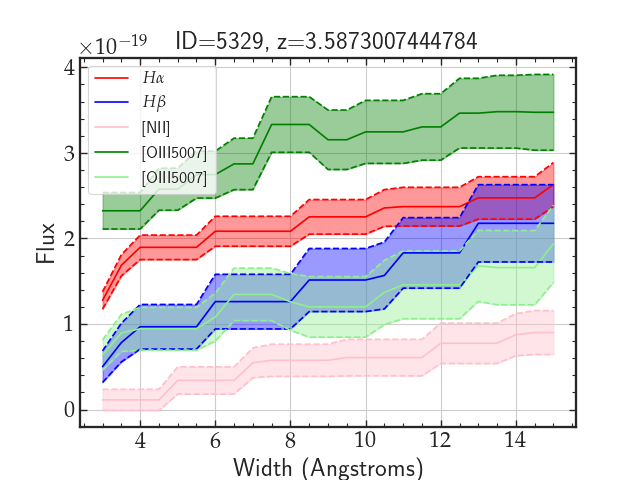

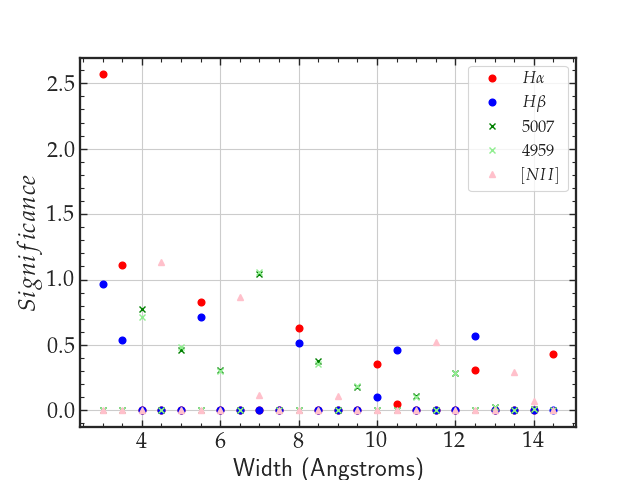

In [12]:
plot_variation_significance(8)

In [ ]:

#Define source path where the files are
source = Path('/home/nicolas/Documents/Research/PhD/JWST-Data/Medium_Resolution/Spectra1D')
jades_folder = source / 'JADES'
mast_folder = source / 'MAST'


#Extract data with Pandas
df = pd.read_csv("list_of_candidates.tsv", sep='\t')
ID_array = df["NIRSpec_ID"]
z_array = df["redshift"]
JADES_files = df["JADES_FILENAME_F170LP-G235M"]
MAST_files = df["MAST_FILENAME_F170LP-G235M"]

#Create arrays to save the data with save_EW()
ID_data = []
z_data = []

mast_Ha_data = []
mast_Ha_err_data = []
mast_Ha_dline_data = []

mast_Hb_data = []
mast_Hb_err_data = []
mast_Hb_dline_data = []

mast_O3_data = []
mast_O3_err_data = []
mast_O3_dline_data = []

mast_o3_data = []
mast_o3_err_data = []
mast_o3_dline_data = []

mast_N2_data = []
mast_N2_err_data = []
mast_N2_dline_data = []

jades_Ha_data = []
jades_Ha_err_data = []
jades_Ha_dline_data = []

jades_Hb_data = []
jades_Hb_err_data = []
jades_Hb_dline_data = []

jades_O3_data = []
jades_O3_err_data = []
jades_O3_dline_data = []

jades_o3_data = []
jades_o3_err_data = []
jades_o3_dline_data = []



def main():
    for index in [0]:
        save_line_fluxes(index)

    LF_data = {
        "ID": ID_data,
        "redshift": z_data,
        "Flux (Ha 6563) MAST": mast_Ha_data,
        "F_err(Ha 6563) MAST": mast_Ha_err_data,
        "Flux (Ha 6563) JADES": jades_Ha_data,
        "F_err(Ha 6563) JADES": jades_Ha_err_data,
        
        "Flux (Hb 4861) MAST": mast_Hb_data,
        "F_err(Hb 4861) MAST": mast_Hb_err_data,
        "Flux (Hb 4861) JADES": jades_Hb_data,
        "F_err(Hb 4861) JADES": jades_Hb_err_data,
        
        "Flux ([OIII]4959) MAST": mast_o3_data,
        "F_err([OIII]4959) MAST": mast_o3_err_data,
        "Flux ([OIII]4959) JADES": jades_o3_data,
        "F_err([OIII]4959) JADES": jades_o3_err_data,       
        
        "Flux ([OIII]5007) MAST": mast_O3_data,
        "F_err([OIII]5007) MAST": mast_O3_err_data,
        "Flux ([OIII]5007) JADES": jades_O3_data,
        "F_err([OIII]5007) JADES": jades_O3_err_data,
        
        "Flux ([NII]6583) MAST": mast_N2_data,
        "F_err([NII]6583) MAST": mast_N2_err_data,

        "Optimal dline (Ha) MAST": mast_Ha_dline_data,
        "Optimal dline (Ha) JADES": jades_Ha_dline_data,
        "Optimal dline (Hb) MAST": mast_Hb_dline_data,
        "Optimal dline (Hb) JADES": jades_Hb_dline_data,    
        "Optimal dline ([OIII]4959) MAST": mast_o3_dline_data,
        "Optimal dline ([OIII]4959) JADES": jades_o3_dline_data,
        "Optimal dline ([OIII]5007) MAST": mast_O3_dline_data,
        "Optimal dline ([OIII]5007) JADES": jades_O3_dline_data,
        
        "Optimal dline ([NII]6583) MAST": mast_N2_dline_data,
        
    }

    LineFlux_df = pd.DataFrame(LF_data)
    #LineFlux_df.to_csv('./Output_data/Line_fluxes_g235m_v5_optimal.tsv', sep='\t', index=False)
    print('Saved line fluxes to Output_data/Line_fluxes_g235m_v5_optimal.tsv')
    return LineFlux_df
        

def compute_significance(flux, flux_err):
    sigmas = [ np.abs ( flux[i] - flux[i+1] ) / np.sqrt( flux_err[i]**2 + flux_err[i+1]**2 ) for i in range(len(flux)-1)]
    return sigmas

def _line_regions_for_dline(dline):
    return {
        'Ha': [6563.0 - dline, 6563.0 + dline],
        'Hb': [4861.0 - dline, 4861.0 + dline],
        'N2': [6583.0 - dline, 6583.0 + dline],
        'O3': [5007.0 - dline, 5007.0 + dline],
        'o3': [4959.0 - dline, 4959.0 + dline],
    }

def compute_line_fluxes_for_dline(lambda_rest, flux, z, dline):
    flux_Jy = flux * u.Jy
    lambda_rest_AA = lambda_rest * u.AA
    line_fluxes = {}
    for line, region in _line_regions_for_dline(dline).items():
        flx, ferr = compute_line_flux(lambda_rest_AA, flux_Jy, region, z)
        line_fluxes[line] = {'flux': flx, 'flux_err': ferr}
    return line_fluxes
#------------------------------------------------
#
#------------------------------------------------            
def find_optimal_dline_from_history(dlines, fluxes, errs, threshold=1.0, min_dline=4.0):
    sigmas = compute_significance(fluxes, errs)
    start_idx = np.searchsorted(dlines, min_dline, side='left')
    
    # Find first instance where sigma is above threshold
    for idx in range(start_idx, len(sigmas) - 1):
        if np.isfinite(sigmas[idx]) and sigmas[idx] >= threshold:
            # Check if next value is below threshold
            if np.isfinite(sigmas[idx + 1]) and sigmas[idx + 1] < threshold:
                # Check if all subsequent values remain below threshold
                
                for check_idx in range(idx + 2, len(sigmas)):
                    if np.isfinite(sigmas[check_idx]) and sigmas[check_idx] >= threshold:
                        
                        break
                
                return dlines[idx + 1], fluxes[idx + 1], errs[idx + 1]
    
    return dlines[int(min_dline)], fluxes[int(min_dline)], errs[int(min_dline)]
#------------------------------------------------
#
#------------------------------------------------

def compute_flux_evolution_for_source(index, source='JADES', start=3.0, stop=15.0, step=0.5):
    if source == 'JADES':
        spec_file = jades_folder / JADES_files[index]
    else:
        spec_file = mast_folder / MAST_files[index]

    try:
        with fits.open(spec_file) as f:
            specdata = f[1].data
    except FileNotFoundError:
        return None

    flux = specdata['FLUX']
    mask = np.isfinite(flux)
    flux_masked = flux[mask]

    lambda_obs = specdata['WAVELENGTH'] * 1e-6 / 1e-10
    lambda_obs = lambda_obs[mask]
    lambda_rest = lambda_obs / (1.0 + float(z_array[index]))

    if source == 'JADES':
        flux_masked = flux_masked * lambda_obs**2 / 2.99792458e-5

    dlines = np.arange(start, stop + 1e-8, step)
    line_names = ['Ha', 'Hb', 'N2', 'O3', 'o3']
    flux_history = {line: [] for line in line_names}
    err_history = {line: [] for line in line_names}

    for dline in dlines:
        results = compute_line_fluxes_for_dline(lambda_rest, flux_masked, z_array[index], dline)
        for line in line_names:
            flux_history[line].append(results[line]['flux'])
            err_history[line].append(results[line]['flux_err'])

    return dlines, flux_history, err_history


def compute_optimal_fluxes_for_source(index, source='JADES',
                                      start=3.0, stop=15.0, step=0.5,
                                      threshold=1.0, min_dline=4.0):
    result = compute_flux_evolution_for_source(index, source, start, stop, step)
    line_names = ['Ha', 'Hb', 'N2', 'O3', 'o3']
    if result is None:
        return {
            line: {'dline': np.nan, 'flux': np.nan, 'flux_err': np.nan}
            for line in line_names
        }

    dlines, flux_history, err_history = result
    optimal = {}
    for line in line_names:
        
        dline, flx, ferr = find_optimal_dline_from_history(
            dlines, flux_history[line], err_history[line],
            threshold=threshold, min_dline=min_dline
        )
        optimal[line] = {'dline': dline, 'flux': flx, 'flux_err': ferr}
    return optimal
#------------------------------------------------
#
#------------------------------------------------
def save_line_fluxes(index):
    z = z_array[index]
    jades_opt = compute_optimal_fluxes_for_source(index, source='JADES')
    mast_opt = compute_optimal_fluxes_for_source(index, source='MAST')

    ID_data.append(ID_array[index])
    z_data.append(z)

    mast_Ha_data.append(mast_opt['Ha']['flux'])
    mast_Ha_err_data.append(mast_opt['Ha']['flux_err'])
    mast_Ha_dline_data.append(mast_opt['Ha']['dline'])

    mast_Hb_data.append(mast_opt['Hb']['flux'])
    mast_Hb_err_data.append(mast_opt['Hb']['flux_err'])
    mast_Hb_dline_data.append(mast_opt['Hb']['dline'])

    mast_O3_data.append(mast_opt['O3']['flux'])
    mast_O3_err_data.append(mast_opt['O3']['flux_err'])
    mast_O3_dline_data.append(mast_opt['O3']['dline'])

    mast_o3_data.append(mast_opt['o3']['flux'])
    mast_o3_err_data.append(mast_opt['o3']['flux_err'])
    mast_o3_dline_data.append(mast_opt['o3']['dline'])

    mast_N2_data.append(mast_opt['N2']['flux'])
    mast_N2_err_data.append(mast_opt['N2']['flux_err'])
    mast_N2_dline_data.append(mast_opt['N2']['dline'])

    jades_Ha_data.append(jades_opt['Ha']['flux'])
    jades_Ha_err_data.append(jades_opt['Ha']['flux_err'])
    jades_Ha_dline_data.append(jades_opt['Ha']['dline'])

    jades_Hb_data.append(jades_opt['Hb']['flux'])
    jades_Hb_err_data.append(jades_opt['Hb']['flux_err'])
    jades_Hb_dline_data.append(jades_opt['Hb']['dline'])

    jades_O3_data.append(jades_opt['O3']['flux'])
    jades_O3_err_data.append(jades_opt['O3']['flux_err'])
    jades_O3_dline_data.append(jades_opt['O3']['dline'])


    jades_o3_data.append(jades_opt['o3']['flux'])
    jades_o3_err_data.append(jades_opt['o3']['flux_err'])
    jades_o3_dline_data.append(jades_opt['o3']['dline'])

    print(f'Saved optimal dline fluxes for ID={ID_array[index]} (z={z})')

main()


TypeError: unsupported operand type(s) for *: 'dict' and 'float'